# T01 – EDA Millas por Galón
Dataset: `mpg` cargado con `seaborn` (`sns.load_dataset`), sin preprocesamiento.

**Variable elegida:** `mpg`

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Reconocimiento del dataset

In [4]:
print('Filas y columnas:', df.shape)
print('Variables numéricas:', df.select_dtypes('number').columns.tolist())
print('Nulos por columna:'); print(df.isna().sum())

Filas y columnas: (398, 9)
Variables numéricas: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Nulos por columna:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


| Pregunta | Respuesta |
|---|---|
| ¿Cuántas filas y columnas tiene? | 398 filas y 9 columnas |
| ¿Qué variables numéricas contiene? | mpg, cylinders, displacement, horsepower, weight, acceleration, model_year |
| ¿Existen valores nulos? ¿En qué columnas? | Sí, 6 nulos, todos en `horsepower` |
| ¿Qué variable analizaremos? | `mpg` |

## Paso 1: Variable elegida: **mpg**
## Paso 2: Medidas descriptivas

In [5]:
x = df['mpg']
pd.DataFrame({'Valor': {
 'n': x.count(), 'Mínimo': x.min(), 'Máximo': x.max(), 'Rango': x.max()-x.min(),
 'Media': x.mean(), 'Mediana': x.median(), 'Desv. estándar': x.std(),
 'CV (%)': x.std()/x.mean()*100}}).round(2)

,Valor
n,398.00
Mínimo,9.00
Máximo,46.60
Rango,37.60
Media,23.51
Mediana,23.00
Desv. estándar,7.82
CV (%),33.24


<div><b>Interpretación del Paso 2: </b><b></b><ul><li>n = 398 autos; mpg va de 9.0 a 46.6 (rango 37.6): hay autos que rinden más de 4 veces que otros.</li><li>Media 23.51 y mediana 23.0: la mitad de los autos rinde 23 mpg o menos. Son casi iguales, la media es un poco mayor.</li><li>Desviación estándar 7.82 y CV 33.2 %: variabilidad moderada-alta (flota heterogénea: motores chicos y grandes).</li></ul></div>

### Tabla de frecuencias
Sturges: k = 1 + 3.322·log10(398) ≈ 10 intervalos; amplitud A = 37.6/10 → 3.8.

In [6]:
k = 10; A = 3.8
limites = np.round(9.0 + A*np.arange(k+1), 1)
f = pd.cut(x, limites, right=False, include_lowest=True).value_counts().sort_index()
tabla = pd.DataFrame({'Intervalo':[f'[{a}, {b})' for a,b in zip(limites[:-1],limites[1:])],
  'f': f.values, 'fa': f.cumsum().values,
  'fr %': (f/len(x)*100).round(2).values, 'Fa %': (f.cumsum()/len(x)*100).round(2).values})
tabla

,Intervalo,f,fa,fr %,Fa %
0,"[9.0, 12.8)",13,13,3.27,3.27
1,"[12.8, 16.6)",78,91,19.60,22.86
2,"[16.6, 20.4)",74,165,18.59,41.46
3,"[20.4, 24.2)",60,225,15.08,56.53
4,"[24.2, 28.0)",55,280,13.82,70.35
5,"[28.0, 31.8)",48,328,12.06,82.41
6,"[31.8, 35.6)",37,365,9.30,91.71
7,"[35.6, 39.4)",23,388,5.78,97.49
8,"[39.4, 43.2)",5,393,1.26,98.74
9,"[43.2, 47.0)",5,398,1.26,100.00


## Paso 3: Visualización

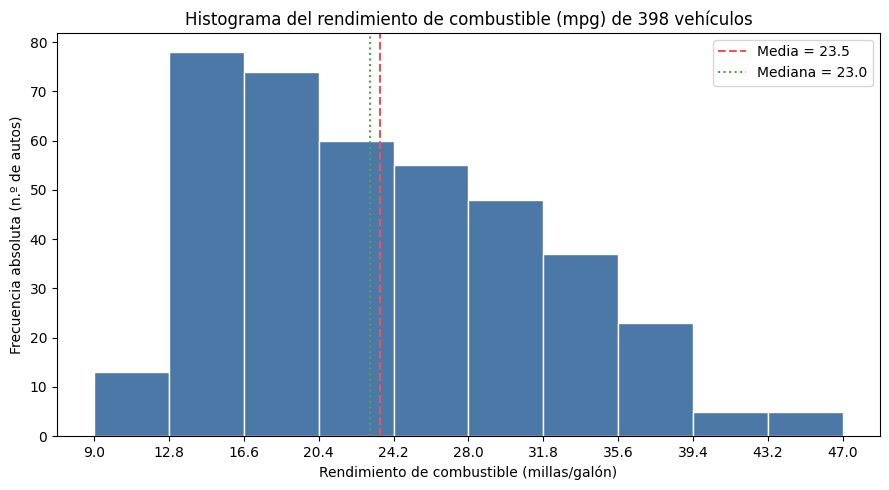

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(x, bins=limites, color='#4C78A8', edgecolor='white')
ax.set_xticks(limites)
ax.set_xlabel('Rendimiento de combustible (millas/galón)')
ax.set_ylabel('Frecuencia absoluta (n.º de autos)')
ax.set_title('Histograma del rendimiento de combustible (mpg) de 398 vehículos')
ax.axvline(x.mean(), color='#E45756', ls='--', label=f'Media = {x.mean():.1f}')
ax.axvline(x.median(), color='#54A24B', ls=':', label=f'Mediana = {x.median():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

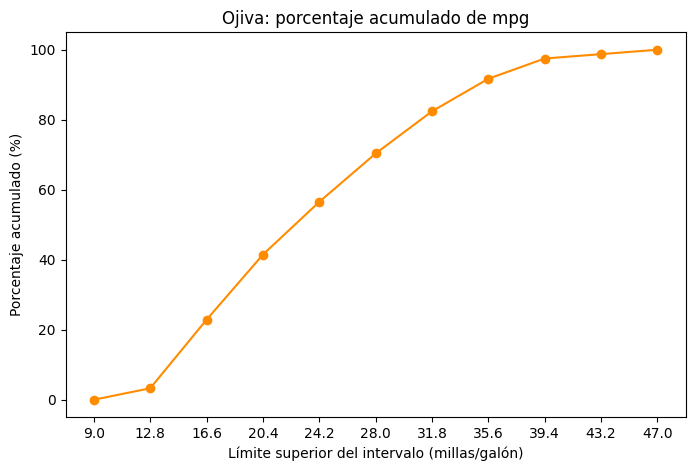

Asimetría: 0.46


In [6]:
plt.figure(figsize=(8,5))
plt.plot(limites, [0]+tabla['Fa %'].tolist(), marker='o', color='darkorange')
plt.xticks(limites); plt.xlabel('Límite superior del intervalo (millas/galón)'); plt.ylabel('Porcentaje acumulado (%)')
plt.title('Ojiva: porcentaje acumulado de mpg')
plt.show()
print('Asimetría:', round(x.skew(),2))

<div><b>Análisis de la forma de la distribución:</b><br><ul><li>Simétrica o sesgada: sesgada a la derecha, dado a que su porcentaje acumulado va en aumento a la derecha</li><li>Mayor frecuencia: en los valores bajos, intervalo [12.8, 16.6) con 78 autos; la cola larga va hacia mpg altos.</li><li>Atípicos: el único es 46.6 mpg, es un valor extremo pero creible.</li></ul></div>

## Paso 4: Interpretación de resultados (mín. 10 líneas)

<div><b> Interpretación integral: </b><br><b></b><ul><li><b>Contexto:</b> mpg = millas recorridas por galón; más alto = más eficiente. 398 autos de 1970-1982.</li><li><b>Tendencia central:</b> media 23.51 vs mediana 23.0; casi iguales, la media algo mayor por la cola derecha (autos muy eficientes).</li><li><b>Dispersión:</b> s = 7.82, CV = 33.2 % → alta variabilidad; no hay un auto 'típico'.</li><li><b>Frecuencias:</b> el intervalo con más autos es [12.8, 16.6): 78 autos = 19.60 %. Le sigue [16.6, 20.4): 74 autos (18.59 %).</li><li><b>Acumulados:</b> en el 3.er intervalo fa = 165 → 165 autos (41.46 %) rinden menos de 20.4 mpg.</li><li><b>Conclusión:</b> la mayoría de autos tiene rendimiento bajo-moderado (≈ 70 % rinde menos de 28 mpg) y pocos son muy eficientes; la variabilidad sugiere que depende de otras variables (cilindros, peso, origen, año).</li></ul></div>

## Paso 5: Preguntas de reflexión

<div><b>1. ¿Qué aporta la ojiva que no aporta el histograma?: </b><br><b></b><ul><li>Histograma: forma y frecuencia por intervalo. Ojiva: acumulados.</li><li>Con la ojiva lees qué % de autos está por debajo de un valor y estimas mediana/percentiles (el 50 % cruza en ≈ 23 mpg).</li><li>Permite comparar distribuciones en la misma escala.</li></ul></div>

<div><b>2. ¿Cómo compararía 4 vs 8 cilindros con tablas de frecuencia?: </b><br><b></b><ul><li>Misma tabla (mismos intervalos) para cada grupo.</li><li>Comparar frecuencias relativas (%), no absolutas, porque los tamaños difieren (204 vs 103).</li><li>Comparar intervalo modal y % acumulados; la ojiva de 8 cilindros subiría mucho antes.</li></ul></div>

## Paso 6: Análisis comparativo
### Pregunta 1: mpg según número de cilindros

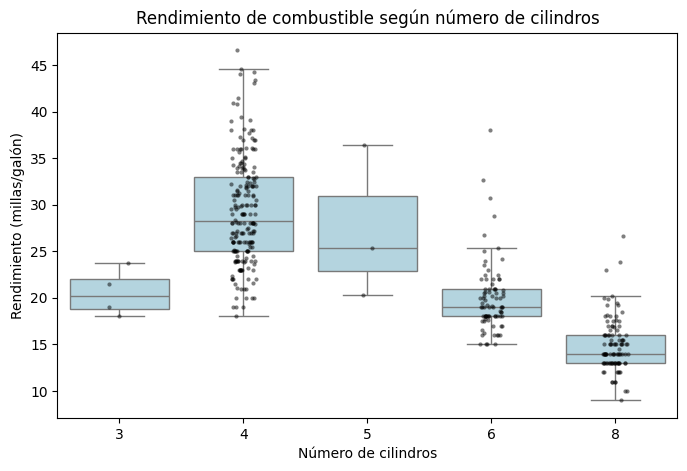

,count,median,mean,std
cylinders,,,,
3,4,20.25,20.55,2.56
4,204,28.25,29.29,5.71
5,3,25.40,27.37,8.23
6,84,19.00,19.99,3.81
8,103,14.00,14.96,2.84


In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='cylinders', y='mpg', color='lightblue', showfliers=False)
sns.stripplot(data=df, x='cylinders', y='mpg', color='black', size=3, alpha=0.5, jitter=True)
plt.xlabel('Número de cilindros')
plt.ylabel('Rendimiento (millas/galón)')
plt.title('Rendimiento de combustible según número de cilindros')
plt.show()
df.groupby('cylinders')['mpg'].agg(['count','median','mean','std']).round(2)

<div><b>Interpretación técnica (Pregunta 1)</b><br><b>Síntesis para guiarte:</b><ul><li>Mediana: 4 cil = 28.3, 6 cil = 19.0, 8 cil = 14.0 -> baja al subir los cilindros. (3 y 5 cilindros tienen solo 4 y 3 autos: no sacar conclusiones fuertes.)</li><li>Mayor dispersión: 4 cilindros (s = 5.71) entre los grupos grandes; agrupa desde compactos muy eficientes hasta autos más pesados. 8 cilindros es el más homogéneo (s = 2.84).</li><li>Solapamiento: 4 y 8 cilindros no se solapan (diferencia clara); 4-6 y 6-8 se solapan poco → sugiere medias distintas.</li><li>Hipótesis ANOVA: H0: u4 = u6 = u8 vs H1: al menos una media es diferente.</li></ul></div>

### Pregunta 2: mpg según país de origen

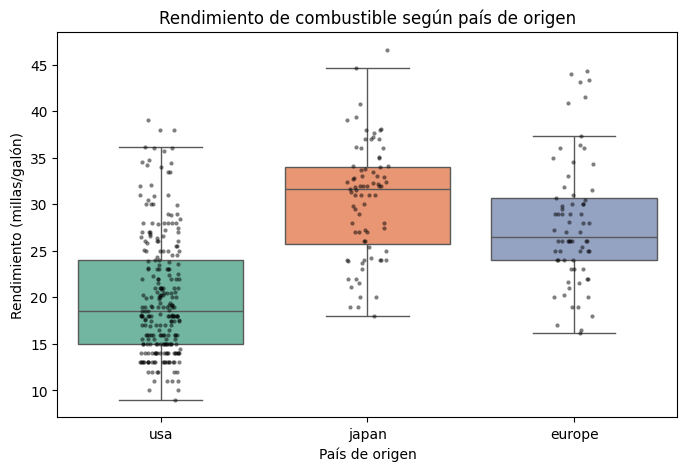

,count,mean,median,std,skew
origin,,,,,
europe,70,27.89,26.5,6.72,0.70
japan,79,30.45,31.6,6.09,0.01
usa,249,20.08,18.5,6.40,0.82


In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='origin', y='mpg', hue='origin', palette='Set2', legend=False, showfliers=False)
sns.stripplot(data=df, x='origin', y='mpg', color='black', size=3, alpha=0.5, jitter=True)
plt.xlabel('País de origen')
plt.ylabel('Rendimiento (millas/galón)')
plt.title('Rendimiento de combustible según país de origen')
plt.show()
df.groupby('origin')['mpg'].agg(['count','mean','median','std','skew']).round(2)

<div><b>Interpretación técnica (Pregunta 2): </b><br><b>Síntesis para guiarte:</b><ul><li>Mejor: Japón (media 30.45, mediana 31.6). Peor: USA (media 20.08, mediana 18.5). Europa en medio (27.89).</li><li>Forma: USA (asimetría 0.82) y Europa (0.70) sesgadas a la derecha; Japón casi simétrica (0.01).</li><li>Varianzas: desviaciones parecidas (USA 6.40, Europa 6.72, Japón 6.09) → se sugiere igualdad de varianzas.</li><li>Variables de confusión: cilindros, peso, cilindrada, potencia y año. USA fabricaba muchos V8 pesados; Japón y Europa, 4 cilindros ligeros.</li></ul></div>

### Pregunta 3: origen y cilindros sobre el rendimiento

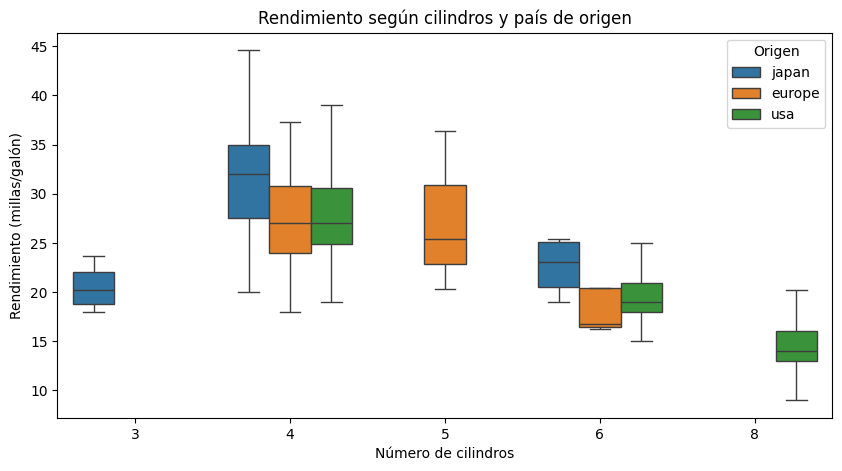

count  median
origin cylinders               
europe 4             63    27.0
       5              3    25.4
       6              4    16.8
japan  3              4    20.2
       4             69    32.0
       6              6    23.1
usa    4             72    27.0
       6             74    19.0
       8            103    14.0

In [11]:
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=df, x='cylinders', y='mpg', hue='origin', showfliers=False)
sns.stripplot(dpalette='dark:black',
              color='black', size=3, alpha=0.5, legend=False, ax=ax)
ax.set_xlabel('Número de cilindros')
ax.set_ylabel('Rendimiento (millas/galón)')
ax.set_title('Rendimiento según cilindros y país de origen')
ax.legend(title='Origen')
plt.show()
df.groupby(['origin','cylinders'])['mpg'].agg(['count','median']).round(1)

<div><b>Interpretación técnica (Pregunta 3): </b><br><ul><li>¿Efecto constante? La dirección sí (más cilindros → menos mpg en todos los orígenes), pero la magnitud cambia: USA 27.0 → 19.0 → 14.0 (4, 6, 8 cil.); Japón 32.0 → 23.1 (4 y 6 cil.); Europa 27.0 → 16.8 (con solo 4 autos de 6 cil.).</li><li>Origen diferenciado: Japón con 4 cilindros rinde más (mediana 32.0 vs 27.0 de USA y Europa). Solo USA tiene autos de 8 cilindros (103).</li><li>Ventaja del gráfico: muestra dos factores a la vez y ayuda a separar el efecto de origen del de cilindros (confusión). Cuidado: hay celdas con pocos datos.</li></ul></div>

### Pregunta 4: composición de cilindros y orígenes por año

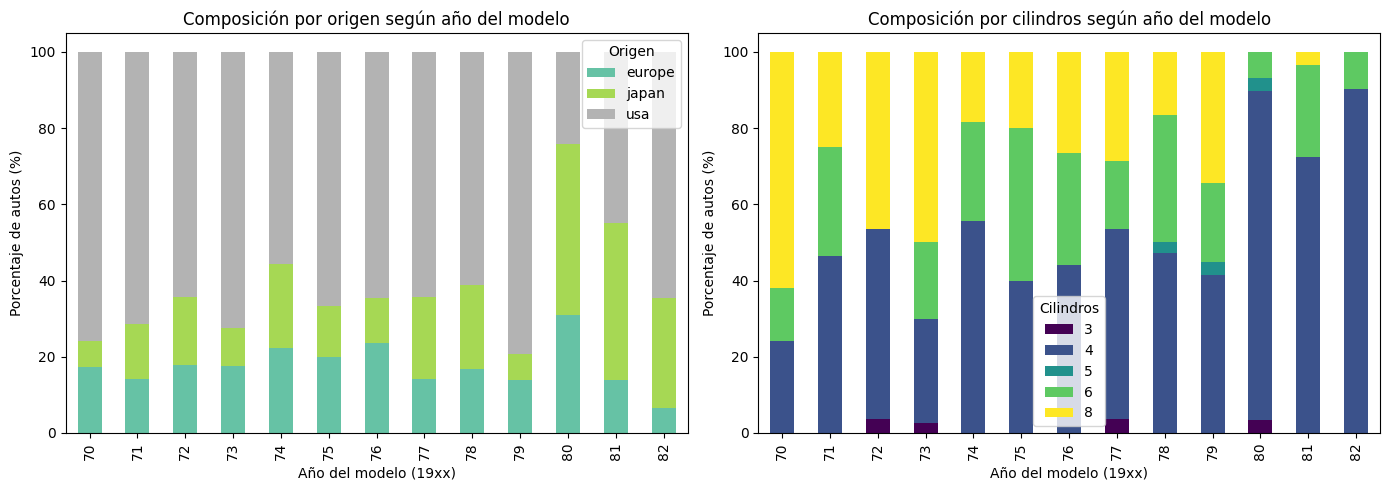

model_year
70    17.7
71    21.2
72    18.7
73    17.1
74    22.7
75    20.3
76    21.6
77    23.4
78    24.1
79    25.1
80    33.7
81    30.3
82    31.7
Name: mpg, dtype: float64

In [15]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
pd.crosstab(df.model_year, df.origin, normalize='index').mul(100).plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Composición por origen según año del modelo'); axes[0].legend(title='Origen')
pd.crosstab(df.model_year, df.cylinders, normalize='index').mul(100).plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Composición por cilindros según año del modelo'); axes[1].legend(title='Cilindros')
for a in axes: a.set_xlabel('Año del modelo (19xx)'); a.set_ylabel('Porcentaje de autos (%)')
plt.tight_layout(); plt.show()
df.groupby('model_year')['mpg'].mean().round(1)

<div><b>Interpretación técnica (Pregunta 4): </b><br><b>Síntesis para guiarte:</b><ul><li>Origen: USA domina casi todo el periodo (≈ 55-80 % hasta 1979); Japón crece al final (≈ 7 % en 1970 → ≈ 29-45 % en 1980-82).</li><li>8 cilindros: sí disminuyó. En 1970 eran 18 de 29 autos (≈ 62 %); en 1980-82 casi desaparecen (0, 1 y 0 autos). Los de 4 cilindros llegan a ≈ 90 % en 1982.</li><li>Relación con mpg: el mpg medio sube de 17.7 (1970) a 31.7 (1982); coherente con menos V8, más 4 cilindros y más autos japoneses.</li></ul></div>

## Paso 7: Diseño de su propio análisis
**Pregunta propuesta:** ¿Cómo se relaciona el peso del vehículo con su rendimiento (mpg) y cambia según el origen?

- **Eje X:** `weight` (lb) · **Eje Y:** `mpg` (millas/galón) · **Color:** `origin`
- **Gráfico:** diagrama de dispersión (ambas variables son cuantitativas continuas y se busca ver la relación; el color distingue el origen).

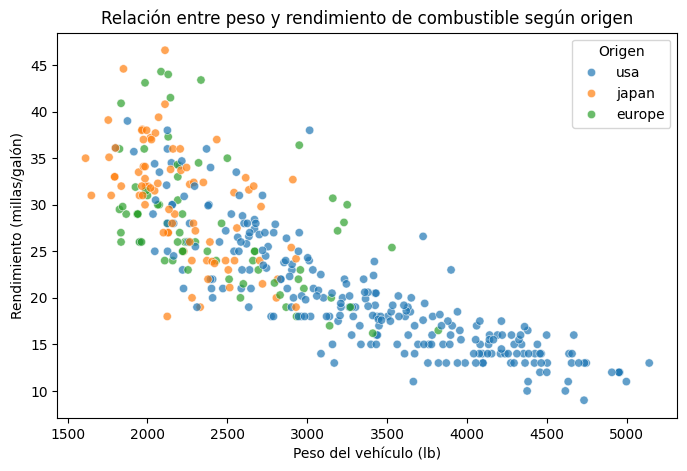

Correlación weight-mpg: -0.832


origin
europe    2423.0
japan     2221.0
usa       3362.0
Name: weight, dtype: float64

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='weight', y='mpg', hue='origin', alpha=.7)
plt.xlabel('Peso del vehículo (lb)'); plt.ylabel('Rendimiento (millas/galón)')
plt.title('Relación entre peso y rendimiento de combustible según origen'); plt.legend(title='Origen')
plt.show()
print('Correlación weight-mpg:', round(df['weight'].corr(df['mpg']),3))
df.groupby('origin')['weight'].mean().round(0)

<div><b>Interpretación técnica (mín. 6 líneas): </b><br><ul><li>Correlación weight–mpg = −0.83: relación negativa y fuerte; a más peso, menos rendimiento.</li><li>Peso medio: USA 3362 lb, Europa 2423 lb, Japón 2221 lb. USA fabrica autos más pesados, lo que explica gran parte de su menor mpg.</li><li>En la nube de puntos, los autos japoneses y europeos se concentran en pesos bajos y mpg altos; los de USA en pesos altos y mpg bajos.</li><li>Aun con pesos parecidos, parece que Japón rinde un poco más: el origen no se explica solo por el peso.</li><li>La relación parece algo curva (no perfectamente lineal); correlación no implica causalidad.</li><li>Limitación: observacional; se podría contrastar con una regresión que incluya peso, cilindros y origen.</li></ul></div>

## Matriz de autoevaluación
| Criterio | ✔ / ✘ | Comentario |
|---|---|---|
| El título describe qué se muestra | ✔ | Cada gráfico indica variable y agrupación |
| Los ejes tienen etiquetas con unidades | ✔ | Millas/galón, lb, % y año |
| El eje Y comienza en cero (cuando aplica) | ✔ | En histograma y barras apiladas sí; en boxplots/dispersión no aplica |
| El color es informativo, no decorativo | ✔ | Representa origen o cilindros |
| Leyenda cuando hay varios grupos | ✔ | Incluida en gráficos con origen/cilindros |
| Sin chartjunk | ✔ | Sin 3D ni adornos |
| El gráfico corresponde al tipo de variable | ✔ | Histograma/ojiva, boxplot, barras apiladas, dispersión |